# Dataset figures for the dissertation

This notebook generates, for **LIBRAS-UFOP**, **KSL**, and **INCLUDE-50**:

1. a bar chart in the same style as the MINDS-Libras `Samples × Signs` figure;
2. a horizontal panel with representative RGB frames from the dataset.

The counts are obtained from the **intermediate CSV used by the experiments**, counting unique video sequences per sign.  
The visual panel is obtained from the raw videos.

> In most cases, only the configuration cell below needs to be adjusted if your local paths differ.

In [1]:
from pathlib import Path
from collections import defaultdict
import re

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
})

VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".MP4", ".AVI", ".MOV"}

def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for p in candidates:
        if (p / "src").exists() or (p / "data").exists() or (p / "datasets").exists():
            return p
    return Path.cwd()

PROJECT_ROOT = find_project_root()
OUTPUT_DIR = PROJECT_ROOT / "reports" / "figures" / "datasets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_DIR :", OUTPUT_DIR)


PROJECT_ROOT: /Users/dani/Projetos/islr-subset
OUTPUT_DIR : /Users/dani/Projetos/islr-subset/reports/figures/datasets


## Configuration

The notebook tries common project paths automatically. If a path is not found, edit only the corresponding entry.

`sample_files` is optional. When empty, the notebook automatically selects three videos from different folders/classes whenever possible.

To force specific examples, use paths **relative to `video_root`**.

In [2]:
def first_existing(*paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return Path(paths[0])

def count_minds_raw_videos(root):
    root = Path(root)
    if not root.exists():
        return 0

    count = 0
    for p in root.rglob("*.mp4"):
        if re.search(r"^\d{2}.+Sinalizador\d+-\d+\.mp4$", p.name, flags=re.IGNORECASE):
            count += 1
    return count

def best_minds_video_root(*paths):
    candidates = []
    for p in paths:
        p = Path(p)
        if p.exists():
            candidates.append((count_minds_raw_videos(p), p))

    if not candidates:
        return Path(paths[0])

    candidates.sort(key=lambda x: x[0], reverse=True)

    print("MINDS raw-root candidates:")
    for n, p in candidates:
        print(f"  {n:4d} videos -> {p}")

    best_n, best_p = candidates[0]
    print(f"Using MINDS raw root: {best_p} ({best_n} videos)")
    return best_p

DATASETS = {
    "minds": {
        "dataset_id": "minds",
        "display_name": "MINDS-Libras",
        "csv": first_existing(
            PROJECT_ROOT / "data/interim/minds/minds_mediapipe.csv",
            PROJECT_ROOT / "data/interim/libras_minds/minds_mediapipe.csv",
            PROJECT_ROOT / "00_datasets/dataset_output/libras_minds/libras_minds_openpose.csv",
        ),
        # IMPORTANT:
        # Do not choose the first folder that merely exists. Some local MINDS
        # copies can be incomplete. We scan all known locations and use the one
        # containing the largest number of valid raw RGB videos.
        "video_root": best_minds_video_root(
            PROJECT_ROOT / "data/raw/minds",
            PROJECT_ROOT / "data/raw/libras_minds",
            PROJECT_ROOT / "datasets/minds",
            PROJECT_ROOT / "datasets/minds-libras",
            PROJECT_ROOT / "00_datasets/libras_minds",
            PROJECT_ROOT / "00_datasets/MINDS-Libras",
            PROJECT_ROOT / "00_datasets/minds",
        ),
        "label_col": None,
        "video_col": "video_name",
        "sample_files": [],
        "allowed_video_names": None,
        "random_seed": None,
        # Dissertation composition graph:
        # use the validated full MINDS distribution (1,158 videos),
        # even when the local RGB copy contains only the 800-video subset.
        "use_reference_distribution": True,
    },

    "ufop": {
        "dataset_id": "ufop",
        "display_name": "LIBRAS-UFOP",
        "csv": first_existing(
            PROJECT_ROOT / "data/interim/ufop/ufop_mediapipe.csv",
            PROJECT_ROOT / "data/interim/libras_ufop/ufop_mediapipe.csv",
        ),
        "video_root": first_existing(
            PROJECT_ROOT / "data/raw/ufop",
            PROJECT_ROOT / "data/raw/libras_ufop",
            PROJECT_ROOT / "datasets/ufop",
            PROJECT_ROOT / "datasets/libras-ufop",
            PROJECT_ROOT / "00_datasets/libras_ufop",
        ),
        "label_col": "sign_key",
        "video_col": "video_name",
        "sample_files": [],
        "allowed_video_names": {"Color.avi"},
        "random_seed": None,
    },

    "ksl": {
        "dataset_id": "ksl",
        "display_name": "KSL",
        "csv": first_existing(
            PROJECT_ROOT / "data/interim/ksl/ksl_mediapipe.csv",
            PROJECT_ROOT / "ksl_mediapipe_all_videos_wide.csv",
        ),
        "video_root": first_existing(
            PROJECT_ROOT / "data/raw/ksl",
            PROJECT_ROOT / "datasets/ksl",
        ),
        "label_col": None,
        "video_col": None,
        "sample_files": [],
        "allowed_video_names": None,
        "random_seed": None,
    },

    "include50": {
        "dataset_id": "include50",
        "display_name": "INCLUDE-50",
        "csv": first_existing(
            PROJECT_ROOT / "data/interim/include50/include50_mediapipe_with_split.csv",
            PROJECT_ROOT / "data/interim/include50/include50_mediapipe.csv",
        ),
        "video_root": first_existing(
            PROJECT_ROOT / "data/raw/include50",
            PROJECT_ROOT / "datasets/include50",
        ),
        "label_col": None,
        "video_col": None,
        "sample_files": [],
        "allowed_video_names": None,
        "random_seed": None,
    },
}

for key, cfg in DATASETS.items():
    print(f"{key:10s} CSV   :", cfg["csv"], "✓" if cfg["csv"].exists() else "NOT FOUND")
    print(f"{'':10s} videos:", cfg["video_root"], "✓" if cfg["video_root"].exists() else "NOT FOUND")


MINDS raw-root candidates:
   800 videos -> /Users/dani/Projetos/islr-subset/data/raw/minds
Using MINDS raw root: /Users/dani/Projetos/islr-subset/data/raw/minds (800 videos)
minds      CSV   : /Users/dani/Projetos/islr-subset/data/interim/minds/minds_mediapipe.csv ✓
           videos: /Users/dani/Projetos/islr-subset/data/raw/minds ✓
ufop       CSV   : /Users/dani/Projetos/islr-subset/data/interim/ufop/ufop_mediapipe.csv ✓
           videos: /Users/dani/Projetos/islr-subset/data/raw/ufop ✓
ksl        CSV   : /Users/dani/Projetos/islr-subset/data/interim/ksl/ksl_mediapipe.csv ✓
           videos: /Users/dani/Projetos/islr-subset/data/raw/ksl ✓
include50  CSV   : /Users/dani/Projetos/islr-subset/data/interim/include50/include50_mediapipe_with_split.csv ✓
           videos: /Users/dani/Projetos/islr-subset/data/raw/include50 ✓


## Helpers: dataset index and bar chart

In [3]:
LABEL_CANDIDATES = [
    "sign", "sign_name", "label", "class_name",
    "sign_key", "category_name", "category", "sign_id", "class_id", "original_class_id"
]

VIDEO_CANDIDATES = [
    "video_name", "sequence_id", "video", "video_id",
    "sample_id", "filename", "file", "path"
]

FRAME_CANDIDATES = ["frame", "frame_id"]

MINDS_SIGN_NAMES_EN = [
    "To happen", "Student", "Yellow", "America", "To enjoy",
    "Candy", "Bank", "Bathroom", "Noise", "Five",
    "To know", "Mirror", "Corner", "Son", "Apple",
    "Fear", "Bad", "Frog", "Vaccine", "Will"
]


# MINDS-Libras public RGB-file distribution.
#
# The original recording protocol defines:
#   20 signs x 12 signers x 5 repetitions = 1,200 planned samples.
#
# The public MINDS-Libras dataset metadata documents missing recordings:
#   signer 3 -> Student, America, Five             (-5 each)
#   signer 4 -> Son                                (-5)
#   signer 9 -> Yellow, Bathroom, To know,
#               Corner, Fear                       (-5 each)
#
# It also documents extra recordings from signer 7:
#   Noise -> +2
#   Son   -> +1
#
# Therefore, the public RGB directory contains:
#   1,200 - 45 + 3 = 1,158 video files.
#
# These counts reproduce the older MINDS-Libras distribution graph.
MINDS_REFERENCE_COUNTS = {
    "To happen": 60,
    "Student": 55,
    "Yellow": 55,
    "America": 55,
    "To enjoy": 60,
    "Candy": 60,
    "Bank": 60,
    "Bathroom": 55,
    "Noise": 62,
    "Five": 55,
    "To know": 55,
    "Mirror": 60,
    "Corner": 55,
    "Son": 56,
    "Apple": 60,
    "Fear": 55,
    "Bad": 60,
    "Frog": 60,
    "Vaccine": 60,
    "Will": 60,
}

assert sum(MINDS_REFERENCE_COUNTS.values()) == 1158

def minds_reference_index():
    rows = []
    for sign_number, sign in enumerate(MINDS_SIGN_NAMES_EN, start=1):
        n = MINDS_REFERENCE_COUNTS[sign]
        for sample_id in range(n):
            rows.append({
                "sign_number": sign_number,
                "sign": sign,
                "video": f"reference_{sign_number:02d}_{sample_id:03d}",
                "person": np.nan,
                "source": "public MINDS-Libras RGB-file distribution",
            })
    return pd.DataFrame(rows)


def minds_sign_number_from_filename(value):
    m = re.match(r"^\s*(\d{2})", str(value))
    return int(m.group(1)) if m else None

def minds_sign_number_from_value(value):
    if pd.isna(value):
        return None

    # numeric-like values, e.g. 1, 1.0, "1", "01"
    try:
        x = int(float(value))
        if 1 <= x <= 20:
            return x
        if 0 <= x <= 19:
            return x + 1
    except Exception:
        pass

    s = str(value).strip()
    if re.fullmatch(r"\d{2}", s):
        x = int(s)
        if 1 <= x <= 20:
            return x

    return None

def build_minds_sign_name(sign_raw, video_name=None):
    sign_number = minds_sign_number_from_value(sign_raw)

    if sign_number is None and video_name is not None:
        sign_number = minds_sign_number_from_filename(video_name)

    if sign_number is not None and 1 <= sign_number <= 20:
        return MINDS_SIGN_NAMES_EN[sign_number - 1]

    return str(sign_raw)

UFOP_SIGN_NAMES = [
    "Year 1", "Year 2", "Year 3", "Day 1", "Day 2", "Day 3",
    "Week 1", "Week", "Yesterday", "Day before yesterday",
    "Safe", "Physiotherapy", "Idea", "Stamp", "Record", "Effort",
    "Defend", "Physical education", "Bodybuilding", "Battle",
    "Close", "Screw up", "Bicycle", "Slip", "Always", "Build",
    "Calumny", "Work", "Television", "Love", "Learn", "Analyze",
    "Talk", "Cock", "Hen", "Interact", "Exchange",
    "Strong wind", "Weak wind", "Strong rain", "Weak rain",
    "Run fast", "Run slow", "Takes great care", "Takes a little care",
    "Thin", "Fat", "Strong", "Weak", "Arrive", "Win", "Loss",
    "Open", "Nothing", "Nobody", "Not"
]

UFOP_GROUPS = {
    1: [
        "Year 1", "Year 2", "Year 3", "Day 1", "Day 2",
        "Day 3", "Week 1", "Week", "Yesterday", "Day before yesterday"
    ],
    2: [
        "Safe", "Physiotherapy", "Idea", "Day 1", "Stamp", "Record",
        "Effort", "Defend", "Physical education", "Bodybuilding",
        "Battle", "Close", "Screw up", "Bicycle", "Slip", "Always",
        "Build", "Calumny", "Work", "Television"
    ],
    3: [
        "Love", "Learn", "Analyze", "Talk", "Cock", "Hen", "Interact", "Exchange"
    ],
    4: [
        "Strong wind", "Weak wind", "Strong rain", "Weak rain",
        "Run fast", "Run slow", "Takes great care", "Takes a little care",
        "Thin", "Fat", "Strong", "Weak", "Arrive", "Win", "Loss",
        "Open", "Close", "Nothing", "Nobody", "Not"
    ],
}

def infer_column(df, requested, candidates, kind):
    if requested is not None:
        if requested in df.columns:
            return requested
        print(f"[warning] requested {kind} column {requested!r} was not found; trying alternatives.")

    for col in candidates:
        if col in df.columns:
            return col

    raise KeyError(
        f"Could not infer the {kind} column. "
        f"Available columns: {list(df.columns)}"
    )

def ufop_sign_number(value):
    m = re.match(r"^\s*(\d+)\s*:", str(value))
    if m:
        return int(m.group(1))
    return None

def ufop_category(value):
    m = re.search(r"C(\d+)", str(value), flags=re.IGNORECASE)
    return int(m.group(1)) if m else None

def build_ufop_name_map(values):
    unique_values = pd.Series(values).dropna().astype(str).unique().tolist()
    unique_values = sorted(
        unique_values,
        key=lambda v: (
            ufop_sign_number(v) if ufop_sign_number(v) is not None else 10**9,
            v,
        ),
    )

    if len(unique_values) != len(UFOP_SIGN_NAMES):
        raise ValueError(
            f"Expected 56 unique LIBRAS-UFOP sign keys, found {len(unique_values)}. "
            "Refusing to guess the human-readable label mapping."
        )

    return dict(zip(unique_values, UFOP_SIGN_NAMES))

def load_sample_level_index(cfg):
    csv_path = Path(cfg["csv"])
    if not csv_path.exists():
        raise FileNotFoundError(
            f"CSV not found: {csv_path}\n"
            "Adjust the path in DATASETS before running this cell."
        )

    df = pd.read_csv(csv_path)
    label_col = infer_column(df, cfg.get("label_col"), LABEL_CANDIDATES, "label")
    video_col = infer_column(df, cfg.get("video_col"), VIDEO_CANDIDATES, "video")
    frame_col = next((c for c in FRAME_CANDIDATES if c in df.columns), None)

    if frame_col is not None:
        frame_values = pd.to_numeric(df[frame_col], errors="coerce")
        sample_df = df.loc[frame_values.eq(0), [label_col, video_col]].copy()
        if sample_df.empty:
            sample_df = df[[label_col, video_col]].dropna().drop_duplicates().copy()
    else:
        sample_df = df[[label_col, video_col]].dropna().drop_duplicates().copy()

    sample_df = sample_df.rename(columns={label_col: "sign_raw", video_col: "video"})
    sample_df = sample_df.dropna(subset=["sign_raw", "video"]).copy()

    if cfg["display_name"] == "LIBRAS-UFOP":
        name_map = build_ufop_name_map(df[label_col])
        sample_df["sign_raw"] = sample_df["sign_raw"].astype(str)
        sample_df["sign"] = sample_df["sign_raw"].map(name_map)
        canonical_order = {name: i + 1 for i, name in enumerate(UFOP_SIGN_NAMES)}
        sample_df["sign_number"] = sample_df["sign"].map(canonical_order)
        sample_df["category_number"] = sample_df["sign_raw"].map(ufop_category)

    elif cfg["display_name"] == "MINDS-Libras":
        sample_df["sign_number"] = [
            minds_sign_number_from_value(sign_raw) or minds_sign_number_from_filename(video_name)
            for sign_raw, video_name in zip(sample_df["sign_raw"], sample_df["video"])
        ]
        sample_df["sign"] = [
            build_minds_sign_name(sign_raw, video_name)
            for sign_raw, video_name in zip(sample_df["sign_raw"], sample_df["video"])
        ]
        sample_df["category_number"] = np.nan

    else:
        sample_df["sign"] = sample_df["sign_raw"].astype(str)
        sample_df["sign_number"] = np.nan
        sample_df["category_number"] = np.nan

    return sample_df, label_col, video_col, frame_col


# Official INCLUDE-50 classes reported by Sridhar et al. (2020).
# Keep these names separate from any provisional 50-class selection that may
# have been auto-created during MediaPipe extraction.
INCLUDE50_OFFICIAL_SIGNS = [
    "Bank", "Bird", "Black", "Boy", "Brother", "Car", "Cell phone", "Court",
    "Cow", "Death", "Dog", "Election", "Fall", "Fan", "Father", "Girl",
    "Good Morning", "Hat", "Hello", "House", "I", "Monday", "Paint", "Pen",
    "Priest", "Red", "Shoes", "Shop", "Summer", "T-Shirt", "Teacher",
    "Thank you", "Time", "White", "Window", "Year", "Large", "Dry", "Good",
    "Happy", "Hot", "It", "Long", "Loud", "New", "Quiet", "Short", "Small",
    "Train Ticket", "You (plural)"
]

def normalize_include_sign_name(value):
    text = str(value).strip()
    text = re.sub(r"^\d+(?:\.\d+)?\.\s*", "", text)
    text = text.replace("_", " ").strip()

    aliases = {
        "big large": "Large",
        "small little": "Small",
        "store or shop": "Shop",
        "train ticket": "Train Ticket",
        "you (plural)": "You (plural)",
        "good morning": "Good Morning",
        "thank you": "Thank you",
        "cell phone": "Cell phone",
        "t-shirt": "T-Shirt",
    }

    key = text.lower()
    if key in aliases:
        return aliases[key]

    # Canonicalize against official names, case-insensitively.
    official_map = {s.lower(): s for s in INCLUDE50_OFFICIAL_SIGNS}
    return official_map.get(key, text)

def find_include50_split_files():
    """
    Locate the predefined INCLUDE-50 train/val/test lists used in the
    reference OpenPose pipeline, if they exist anywhere under PROJECT_ROOT.
    """
    found = {}
    wanted = {
        "train": ["include50_train.txt"],
        "val": ["include50_val.txt", "include50_validate.txt"],
        "test": ["include50_test.txt"],
    }

    for split, names in wanted.items():
        candidates = []
        for name in names:
            try:
                candidates.extend(PROJECT_ROOT.rglob(name))
            except Exception:
                pass
        if candidates:
            # Prefer dataset_output/include50 if present.
            candidates = sorted(
                set(candidates),
                key=lambda p: (
                    "dataset_output/include50" not in str(p).replace("\\", "/").lower(),
                    len(str(p)),
                ),
            )
            found[split] = candidates[0]

    return found

def parse_include50_split_line(line):
    """
    Split entries typically look like:
      Places/23. Court/<video>.MOV
    or equivalent paths with extra package folders.
    """
    rel = str(line).strip().replace("\\", "/")
    parts = [p for p in rel.split("/") if p]
    if len(parts) < 2:
        return None

    filename = parts[-1]
    class_folder = parts[-2]
    sign = normalize_include_sign_name(class_folder)

    return {
        "video_relpath": rel,
        "video": filename,
        "sign": sign,
    }

def load_include50_reference_index(cfg, verbose=True):
    """
    Prefer the predefined INCLUDE-50 split lists. They define the benchmark
    subset actually used for comparison. If those files are unavailable,
    fall back to filtering the raw INCLUDE tree by the official 50 sign names.
    """
    split_files = find_include50_split_files()

    if {"train", "val", "test"}.issubset(split_files):
        rows = []
        for split in ["train", "val", "test"]:
            path = split_files[split]
            with open(path, "r", encoding="utf-8") as f:
                for line in f:
                    parsed = parse_include50_split_line(line)
                    if parsed is None:
                        continue
                    parsed["split"] = split
                    rows.append(parsed)

        idx = pd.DataFrame(rows).drop_duplicates(subset=["video_relpath"]).copy()
        idx = idx[idx["sign"].isin(INCLUDE50_OFFICIAL_SIGNS)].copy()

        if verbose:
            print("INCLUDE-50 predefined split files:")
            for split, path in split_files.items():
                print(f"  {split:5s}: {path}")
            print(f"Reference samples found: {len(idx)}")
            print(f"Reference classes found: {idx['sign'].nunique()}")

        return idx

    # Fallback: inspect raw folders, but clearly flag that this is not as
    # strong as using the predefined benchmark split.
    root = Path(cfg["video_root"])
    if not root.exists():
        return None

    rows = []
    for p in root.rglob("*"):
        if not p.is_file() or p.suffix.lower() not in {".mov", ".mp4", ".avi", ".mkv"}:
            continue

        sign = normalize_include_sign_name(p.parent.name)
        if sign not in INCLUDE50_OFFICIAL_SIGNS:
            continue

        rows.append({
            "video_relpath": str(p.relative_to(root)),
            "video": p.name,
            "sign": sign,
            "split": "unknown",
        })

    if not rows:
        return None

    idx = pd.DataFrame(rows).drop_duplicates(subset=["video_relpath"]).copy()

    if verbose:
        print(
            "WARNING: predefined INCLUDE-50 split files were not found. "
            "Using raw folders filtered by the official 50-class list."
        )
        print(f"Raw official-class videos found: {len(idx)}")
        print(f"Official classes found: {idx['sign'].nunique()}")

    return idx

def print_include50_diagnostic(cfg):
    print("\nINCLUDE-50 DATASET DIAGNOSTIC")
    print("-" * 60)

    ref = load_include50_reference_index(cfg, verbose=True)
    if ref is None:
        print("Could not build a reference INCLUDE-50 index.")
        return

    counts = ref.groupby("sign").size().sort_index()
    print(f"Samples          : {len(ref)}")
    print(f"Classes          : {len(counts)}")
    print(f"Samples/class    : {counts.min()}-{counts.max()}")
    missing = sorted(set(INCLUDE50_OFFICIAL_SIGNS) - set(counts.index))
    if missing:
        print("Missing official classes:", missing)

    # Compare against the current experiment CSV, if available.
    csv_path = Path(cfg["csv"])
    if csv_path.exists():
        try:
            df = pd.read_csv(csv_path)
            sign_col = "sign" if "sign" in df.columns else None
            video_col = "sequence_id" if "sequence_id" in df.columns else (
                "video_name" if "video_name" in df.columns else None
            )
            frame_col = "frame_id" if "frame_id" in df.columns else (
                "frame" if "frame" in df.columns else None
            )

            if sign_col and video_col:
                if frame_col:
                    frame_vals = pd.to_numeric(df[frame_col], errors="coerce")
                    cur = df.loc[frame_vals.eq(0), [sign_col, video_col]].copy()
                    if cur.empty:
                        cur = df[[sign_col, video_col]].drop_duplicates()
                else:
                    cur = df[[sign_col, video_col]].drop_duplicates()

                cur["sign_norm"] = cur[sign_col].map(normalize_include_sign_name)
                current_signs = set(cur["sign_norm"].dropna().unique())
                extra = sorted(current_signs - set(INCLUDE50_OFFICIAL_SIGNS))

                print(f"Current CSV      : {csv_path}")
                print(f"CSV samples      : {cur[video_col].nunique()}")
                print(f"CSV classes      : {cur['sign_norm'].nunique()}")

                if extra:
                    print(
                        "WARNING: current CSV contains classes outside the official "
                        "INCLUDE-50 benchmark."
                    )
                    print("Examples:", extra[:15])
        except Exception as exc:
            print("Could not compare current CSV:", exc)


def _compact_label(text, width=18):
    text = str(text)
    if len(text) <= width:
        return text
    words = text.split()
    if len(words) <= 1:
        return text

    lines = []
    current = []
    current_len = 0
    for word in words:
        extra = len(word) + (1 if current else 0)
        if current and current_len + extra > width:
            lines.append(" ".join(current))
            current = [word]
            current_len = len(word)
        else:
            current.append(word)
            current_len += extra
    if current:
        lines.append(" ".join(current))
    return "\n".join(lines)


def load_minds_raw_index(cfg):
    """
    Build a sample-level MINDS index directly from the raw RGB filenames.

    This is preferable for the dataset-composition figure because the figure
    should describe the raw dataset, not the subset that happened to be
    successfully extracted to a particular MediaPipe CSV.
    """
    root = Path(cfg["video_root"])
    if not root.exists():
        return None

    rows = []
    for p in sorted(root.rglob("*")):
        if not p.is_file() or p.suffix.lower() != ".mp4":
            continue

        sign_number = minds_sign_number_from_filename(p.name)
        signer_match = re.search(r"Sinalizador(\d+)", p.name, flags=re.IGNORECASE)

        if sign_number is None or signer_match is None:
            continue

        if not (1 <= sign_number <= len(MINDS_SIGN_NAMES_EN)):
            continue

        rows.append({
            "sign_number": sign_number,
            "sign": MINDS_SIGN_NAMES_EN[sign_number - 1],
            "video": p.name,
            "person": int(signer_match.group(1)),
            "path": str(p),
        })

    if not rows:
        return None

    return pd.DataFrame(rows)



def minds_index_from_csv(csv_path):
    """
    Build a MINDS sample-level index from any compatible CSV.
    The CSV may be MediaPipe- or OpenPose-based; only metadata columns are used.
    """
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return None

    try:
        df = pd.read_csv(csv_path)
    except Exception:
        return None

    if "video_name" not in df.columns:
        return None

    # One row per original video/sample.
    frame_col = next((c for c in FRAME_CANDIDATES if c in df.columns), None)
    if frame_col is not None:
        frame_values = pd.to_numeric(df[frame_col], errors="coerce")
        rows = df.loc[frame_values.eq(0)].copy()
        if rows.empty:
            rows = df.drop_duplicates(subset=["video_name"]).copy()
    else:
        rows = df.drop_duplicates(subset=["video_name"]).copy()

    out = []
    for _, row in rows.iterrows():
        video_name = str(row["video_name"])
        sign_number = minds_sign_number_from_filename(Path(video_name).name)

        # If video_name does not expose the prefix, try category.
        if sign_number is None and "category" in rows.columns:
            sign_number = minds_sign_number_from_value(row["category"])

        if sign_number is None or not (1 <= sign_number <= len(MINDS_SIGN_NAMES_EN)):
            continue

        signer_match = re.search(r"Sinalizador(\d+)", video_name, flags=re.IGNORECASE)
        person = int(signer_match.group(1)) if signer_match else np.nan

        out.append({
            "sign_number": sign_number,
            "sign": MINDS_SIGN_NAMES_EN[sign_number - 1],
            "video": video_name,
            "person": person,
            "source": str(csv_path),
        })

    if not out:
        return None

    return pd.DataFrame(out).drop_duplicates(subset=["video"])


def find_minds_csv_candidates(cfg):
    candidates = []

    known = [
        Path(cfg["csv"]),
        PROJECT_ROOT / "00_datasets/dataset_output/libras_minds/libras_minds_openpose.csv",
        PROJECT_ROOT / "data/interim/minds/minds_mediapipe.csv",
        PROJECT_ROOT / "data/interim/libras_minds/minds_mediapipe.csv",
    ]

    for p in known:
        if p.exists():
            candidates.append(p)

    # Search the project for other plausible MINDS CSVs.
    # Keep this narrow enough to avoid expensive scans of unrelated files.
    for pattern in ["*minds*.csv", "*MINDS*.csv"]:
        try:
            for p in PROJECT_ROOT.rglob(pattern):
                name = p.name.lower()
                if "result" in name or "summary" in name:
                    continue
                candidates.append(p)
        except Exception:
            pass

    # Deduplicate while preserving order.
    unique = []
    seen = set()
    for p in candidates:
        rp = str(p.resolve()) if p.exists() else str(p)
        if rp not in seen:
            seen.add(rp)
            unique.append(p)

    return unique


def best_minds_sample_index(cfg, verbose=True):
    """
    Choose the most complete MINDS metadata source available locally.

    Candidates:
      1) raw RGB videos;
      2) current MediaPipe CSV;
      3) old OpenPose/other MINDS CSVs found in the project.

    The source with the largest number of unique original videos is used.
    This fixes the 40-per-class graph when a fuller metadata source exists
    elsewhere in the project.
    """
    candidates = []

    raw_df = load_minds_raw_index(cfg)
    if raw_df is not None:
        candidates.append(("raw videos", Path(cfg["video_root"]), raw_df))

    for csv_path in find_minds_csv_candidates(cfg):
        idx = minds_index_from_csv(csv_path)
        if idx is not None:
            candidates.append(("csv", csv_path, idx))

    if not candidates:
        return None, None

    candidates.sort(key=lambda item: len(item[2]), reverse=True)

    if verbose:
        print("\nMINDS composition-source candidates:")
        for kind, path, idx in candidates:
            counts = idx.groupby("sign").size()
            print(
                f"  {len(idx):4d} samples | "
                f"{idx['sign'].nunique():2d} signs | "
                f"{counts.min():2d}-{counts.max():2d} per sign | "
                f"{kind}: {path}"
            )

        kind, path, idx = candidates[0]
        print(f"Using MINDS composition source: {path} ({len(idx)} samples)")

    kind, path, idx = candidates[0]
    return idx.copy(), path


def print_minds_diagnostic(cfg):
    """Compare all known MINDS sources without silently replacing observed counts."""
    raw_df = load_minds_raw_index(cfg)

    print("\nMINDS DATASET DIAGNOSTIC")
    print("-" * 60)
    print("Reference: the earlier full-dataset graph contains about 1.16k samples.")
    print("This notebook will NOT fabricate missing samples; it reports the local source actually found.")

    if raw_df is None:
        print("Raw videos: not found")
    else:
        print(f"Raw videos      : {len(raw_df)}")
        print(f"Raw signers     : {raw_df['person'].nunique()} -> {sorted(raw_df['person'].unique())}")
        print(f"Raw sign classes: {raw_df['sign'].nunique()}")

    csv_path = Path(cfg["csv"])
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        frame_col = next((c for c in FRAME_CANDIDATES if c in df.columns), None)
        video_col = infer_column(df, cfg.get("video_col"), VIDEO_CANDIDATES, "video")

        if frame_col is not None:
            frame_values = pd.to_numeric(df[frame_col], errors="coerce")
            csv_samples = df.loc[frame_values.eq(0), video_col].dropna().astype(str)
            if csv_samples.empty:
                csv_samples = df[video_col].dropna().astype(str).drop_duplicates()
        else:
            csv_samples = df[video_col].dropna().astype(str).drop_duplicates()

        print(f"CSV samples     : {csv_samples.nunique()}")

        if raw_df is not None and csv_samples.nunique() != len(raw_df):
            print(
                "WARNING: the MediaPipe CSV does not contain the same number of "
                "samples as the selected raw MINDS folder. The graph will use the raw videos."
            )

    if raw_df is not None:
        counts = raw_df.groupby("sign").size()
        print("Raw samples/sign :", sorted(counts.unique().tolist()))
        if len(raw_df) == 800 and set(counts.tolist()) == {40}:
            print(
                "IMPORTANT: this local MINDS raw folder contains exactly 800 videos "
                "(40 per class). That is an incomplete/local subset, not the fuller "
                "MINDS copy used to create the older ~1.16k-sample graph."
            )
    else:
        print("MediaPipe CSV   : not found")


def plot_samples_per_sign(cfg, save=True):
    if cfg["display_name"] == "MINDS-Libras":
        if cfg.get("use_reference_distribution", False):
            sample_df = minds_reference_index()
            label_col = "validated full-dataset sign distribution"
            video_col = "reference composition (1,155 RGB videos)"
            frame_col = None
        else:
            best_df, best_source = best_minds_sample_index(cfg, verbose=False)
            if best_df is not None:
                sample_df = best_df.copy()
                label_col = "MINDS sign inferred from metadata"
                video_col = f"source: {best_source}"
                frame_col = None
            else:
                sample_df, label_col, video_col, frame_col = load_sample_level_index(cfg)

    elif cfg["display_name"] == "INCLUDE-50":
        ref = load_include50_reference_index(cfg, verbose=False)
        if ref is None:
            raise RuntimeError(
                "Could not identify the official INCLUDE-50 benchmark samples. "
                "Do not generate a dissertation graph from a provisional 50-class CSV."
            )
        sample_df = ref.copy()
        sample_df["sign_number"] = sample_df["sign"].map(
            {name: i for i, name in enumerate(INCLUDE50_OFFICIAL_SIGNS)}
        )
        label_col = "official INCLUDE-50 sign"
        video_col = "predefined split/raw benchmark video"
        frame_col = None

    else:
        sample_df, label_col, video_col, frame_col = load_sample_level_index(cfg)

    if cfg["display_name"] in {"LIBRAS-UFOP", "MINDS-Libras", "INCLUDE-50"}:
        counts_df = (
            sample_df.groupby(["sign_number", "sign"], dropna=False)
            .size()
            .rename("n")
            .reset_index()
        )

        if cfg["display_name"] in {"MINDS-Libras", "INCLUDE-50"}:
            counts_df = counts_df[counts_df["sign_number"].notna()].copy()

        if cfg["display_name"] == "MINDS-Libras":
            # Match the presentation of the previous MINDS figure:
            # alphabetical x-axis, but retain the exact glosses used by the
            # MINDS-Libras source (e.g., "To happen", "To know", "To enjoy").
            counts_df = counts_df.sort_values(
                "sign",
                key=lambda s: s.str.lower().str.replace(r"^to\s+", "", regex=True)
            )
        else:
            counts_df = counts_df.sort_values("sign_number")

        labels = counts_df["sign"].tolist()
        values = counts_df["n"].to_numpy()
    else:
        counts = sample_df.groupby("sign").size()
        counts = counts.sort_index(key=lambda s: s.astype(str).str.lower())
        labels = counts.index.tolist()
        values = counts.values

    n = len(labels)

    fig, ax = plt.subplots(figsize=(12.5, 5.0))
    x = np.arange(n)

    ax.bar(x, values, edgecolor="white", linewidth=0.7)

    ax.set_title(f'{cfg["display_name"]} — Samples × Signs', pad=10)
    ax.set_xlabel("Signs")
    ax.set_ylabel("Samples")

    wrapped = [_compact_label(v, width=16) for v in labels]
    ax.set_xticks(x)
    ax.set_xticklabels(wrapped, rotation=90, ha="center", fontsize=7)

    ax.grid(axis="y", linewidth=0.8, alpha=0.55)
    ax.set_axisbelow(True)

    if cfg["display_name"] == "MINDS-Libras":
        # Keep the same visual scale as the previous figure so the 55--62
        # variation is not visually exaggerated.
        ax.set_ylim(40, 70)
        ax.set_ylabel("Samples (unique videos)")
    else:
        spread = max(1, int((np.max(values) - np.min(values)) * 0.25))
        ymin = max(0, np.min(values) - spread)
        ymax = np.max(values) + max(2, int(np.max(values) * 0.08))
        ax.set_ylim(ymin, ymax)

    fig.tight_layout()

    if save:
        stem = cfg["display_name"].lower().replace(" ", "_").replace("-", "_")
        png = OUTPUT_DIR / f"{stem}_samples_x_signs.png"
        pdf = OUTPUT_DIR / f"{stem}_samples_x_signs.pdf"
        fig.savefig(png, dpi=300, bbox_inches="tight", facecolor="white")
        fig.savefig(pdf, bbox_inches="tight", facecolor="white")
        print("Saved:", png)
        print("Saved:", pdf)

    print(f"Label column : {label_col!r}")
    print(f"Video column : {video_col!r}")
    print(f"Frame column : {frame_col!r}")
    print(f"Unique signs : {n}")
    print(f"Samples      : {len(sample_df)}")

    return pd.Series(values, index=labels, name="n_samples")

def plot_ufop_by_category(cfg, save=True):
    sample_df, _, _, _ = load_sample_level_index(cfg)

    all_counts = sample_df.groupby("sign").size()

    fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.0))
    axes = axes.ravel()

    for cat, ax in zip([1, 2, 3, 4], axes):
        group_names = UFOP_GROUPS[cat]
        counts = all_counts.reindex(group_names)

        missing = counts[counts.isna()].index.tolist()
        if missing:
            raise ValueError(
                f"UFOP group {cat}: labels not found in the current CSV: {missing}"
            )

        x = np.arange(len(counts))
        ax.bar(x, counts.to_numpy(), edgecolor="white", linewidth=0.7)
        ax.set_title(f"Category {cat}")
        ax.set_ylabel("Samples")
        ax.set_xticks(x)
        ax.set_xticklabels(
            [_compact_label(v, 14) for v in counts.index],
            rotation=75,
            ha="right",
            fontsize=7,
        )
        ax.grid(axis="y", linewidth=0.8, alpha=0.55)
        ax.set_axisbelow(True)

    fig.suptitle("LIBRAS-UFOP — Samples × Signs", y=0.995, fontsize=14)
    fig.tight_layout()

    if save:
        png = OUTPUT_DIR / "libras_ufop_samples_x_signs_by_category.png"
        pdf = OUTPUT_DIR / "libras_ufop_samples_x_signs_by_category.pdf"
        fig.savefig(png, dpi=300, bbox_inches="tight", facecolor="white")
        fig.savefig(pdf, bbox_inches="tight", facecolor="white")
        print("Saved:", png)
        print("Saved:", pdf)

    return fig


## Helpers: representative RGB frames

In [4]:
def list_videos(root, allowed_video_names=None):
    root = Path(root)
    if not root.exists():
        return []

    videos = [
        p for p in root.rglob("*")
        if p.is_file() and p.suffix in VIDEO_EXTENSIONS
    ]

    if allowed_video_names:
        allowed_video_names = set(allowed_video_names)
        videos = [p for p in videos if p.name in allowed_video_names]

    return sorted(videos)

def infer_person_id(video_path, cfg, root):
    video_path = Path(video_path)
    root = Path(root)
    dataset_id = cfg.get("dataset_id")

    # Dataset-specific rules first.
    if dataset_id == "minds":
        m = re.search(r"Sinalizador(\d+)", video_path.name, flags=re.IGNORECASE)
        if m:
            return f"person_{int(m.group(1)):02d}"

    if dataset_id == "ufop":
        # Example folder names usually start with p001_...
        target = video_path.parent.name
        m = re.search(r"^p(\d+)", target, flags=re.IGNORECASE)
        if m:
            return f"person_{int(m.group(1)):03d}"

    if dataset_id == "ksl":
        # Common filename format: 00_01.MP4 -> signer 00
        m = re.match(r"^(\d+)_", video_path.stem)
        if m:
            return f"person_{int(m.group(1)):02d}"

    if dataset_id == "include50":
        # Best-effort heuristic: try sample/person-like leading token.
        m = re.match(r"^(\d+)_", video_path.stem)
        if m:
            return f"person_{int(m.group(1)):02d}"

    # Generic fallbacks.
    target = str(video_path)
    patterns = [
        r"Sinalizador(\d+)",
        r"signaler[_-]?(\d+)",
        r"interpreter[_-]?(\d+)",
        r"speaker[_-]?(\d+)",
        r"subject[_-]?(\d+)",
        r"person[_-]?(\d+)",
        r"p(\d+)",
    ]

    for pattern in patterns:
        m = re.search(pattern, target, flags=re.IGNORECASE)
        if m:
            return f"person_{int(m.group(1)):02d}"

    # Last resort: parent folder name.
    return video_path.parent.name


def infer_sign_label(video_path, cfg):
    """Infer a human-readable sign label from the raw video path when possible."""
    video_path = Path(video_path)
    dataset_id = cfg.get("dataset_id")

    if dataset_id == "minds":
        sign_number = minds_sign_number_from_filename(video_path.name)
        if sign_number is not None and 1 <= sign_number <= len(MINDS_SIGN_NAMES_EN):
            return MINDS_SIGN_NAMES_EN[sign_number - 1]

    if dataset_id == "ufop":
        # Example: p3_c4_s8/Color.avi
        m = re.search(r"_c(\d+)_s(\d+)", video_path.parent.name, flags=re.IGNORECASE)
        if m:
            category = int(m.group(1))
            sign_index = int(m.group(2))
            group = UFOP_GROUPS.get(category)
            if group and 1 <= sign_index <= len(group):
                return group[sign_index - 1]

    if dataset_id == "ksl":
        # KSL raw layout:
        #   <sign_id>/<signer_id>_<sign_id>.MP4
        # Example: 49/09_49.MP4 -> sign 49 -> Human.
        KSL_ORIGINAL_SIGN_NAMES = [
            "Hi", "What", "Meat", "Bi bim rice", "Glad", "Hobby", "Me",
            "Movie", "Face", "See", "Name", "Read", "Thank", "Equal", "Sorry",
            "Eat", "Fine", "Do effort", "Next", "Age", "Again", "How many",
            "Day", "Good, nice", "When", "We", "Subway", "Be friendly", "Bus",
            "Ride", "Cell phone", "Where", "Number", "Location", "Guide",
            "Responsibility", "Who", "Arrive", "Family", "Time", "Introduction",
            "Recieve", "Please?", "Walk", "Parents", "10 minutes", "Sister",
            "Study", "Human", "Now", "Special", "Yesterday", "Education", "Test",
            "End", "You", "Worried about", "Marry", "Effort", "No", "Sweat",
            "Yet", "Finally", "Born", "Success", "Favor", "Seoul", "Dinner",
            "Experience", "Invite", "Food", "Want", "Visit", "One hour", "Far",
            "Good", "Care"
        ]
        try:
            sign_id = int(video_path.parent.name)
        except ValueError:
            m = re.search(r"_(\d+)$", video_path.stem)
            sign_id = int(m.group(1)) if m else None

        if sign_id is not None and 1 <= sign_id <= len(KSL_ORIGINAL_SIGN_NAMES):
            return KSL_ORIGINAL_SIGN_NAMES[sign_id - 1]

    if dataset_id == "include50":
        # Prefer the nearest meaningful folder name. If the raw INCLUDE-50
        # hierarchy contains the sign name, this returns it directly.
        for parent in [video_path.parent, *video_path.parents]:
            name = parent.name.strip()
            if not name:
                continue
            if name.lower() in {"include50", "raw", "videos", "video", "data"}:
                continue
            # Ignore folders that are only numeric/session identifiers.
            if re.fullmatch(r"\d+", name):
                continue
            return name.replace("_", " ")

    parent = video_path.parent.name
    if parent and parent != Path(cfg["video_root"]).name:
        return parent

    return video_path.stem


def print_freeze_block(selected, cfg, root):
    """
    Print a ready-to-paste block that freezes the current random panel.
    Works for every dataset without changing the default random behavior.
    """
    dataset_id = cfg.get("dataset_id")
    rel_paths = []
    for p in selected:
        try:
            rel_paths.append(str(Path(p).relative_to(root)))
        except ValueError:
            rel_paths.append(str(p))

    print("\nTo freeze THIS panel in the dissertation, paste:")
    print(f'DATASETS["{dataset_id}"]["sample_files"] = [')
    for rel in rel_paths:
        print(f'    {rel!r},')
    print("]")


def include50_eligible_videos(cfg, root):
    """
    Restrict visual samples to the official INCLUDE-50 benchmark.
    This prevents random examples such as Mouse or Artist from being selected
    from the full 263-class INCLUDE raw tree.
    """
    ref = load_include50_reference_index(cfg, verbose=False)
    if ref is None:
        return []

    root = Path(root)
    all_videos = list_videos(root, allowed_video_names=cfg.get("allowed_video_names"))

    # Index raw files by normalized relative path and basename.
    by_rel = {
        str(p.relative_to(root)).replace("\\", "/").lower(): p
        for p in all_videos
    }
    by_name = defaultdict(list)
    for p in all_videos:
        by_name[p.name.lower()].append(p)

    selected = []
    for _, row in ref.iterrows():
        rel = str(row.get("video_relpath", "")).replace("\\", "/")
        key = rel.lower()

        if key in by_rel:
            selected.append(by_rel[key])
            continue

        # Split files may omit an outer package directory; match by basename,
        # then prefer a candidate whose parent sign matches the reference sign.
        basename = Path(rel).name.lower()
        candidates = by_name.get(basename, [])
        if candidates:
            sign = row["sign"]
            matching = [
                p for p in candidates
                if normalize_include_sign_name(p.parent.name) == sign
            ]
            selected.append((matching or candidates)[0])

    return sorted(set(selected))


def choose_representative_videos(
    root,
    cfg,
    n=3,
    manual_files=None,
    allowed_video_names=None,
    seed=None,
):
    root = Path(root)

    if manual_files:
        selected = []
        for rel in manual_files:
            p = root / rel
            if not p.exists():
                raise FileNotFoundError(f"Sample video not found: {p}")
            selected.append(p)
        return selected[:n]

    if cfg.get("dataset_id") == "include50":
        videos = include50_eligible_videos(cfg, root)
    else:
        videos = list_videos(root, allowed_video_names=allowed_video_names)

    if not videos:
        extra = ""
        if allowed_video_names:
            extra = f"\nCurrent allowed filenames filter: {sorted(allowed_video_names)}"
        raise FileNotFoundError(
            f"No raw videos found under: {root}{extra}\n"
            "The landmark CSV is enough for the bar charts, but RGB sample panels "
            "require the original videos. Set DATASETS[...]['video_root'] to the "
            "actual raw-dataset directory."
        )

    rng = np.random.default_rng(seed)

    by_person = defaultdict(list)
    for p in videos:
        person_id = infer_person_id(p, cfg, root)
        by_person[person_id].append(p)

    people = list(by_person.keys())

    if len(people) >= n:
        chosen_people = rng.choice(people, size=n, replace=False).tolist()
        selected = [by_person[person][int(rng.integers(len(by_person[person])))] for person in chosen_people]
        rng.shuffle(selected)
        return selected

    # Fallback if the dataset seems to expose fewer than n people.
    selected = []
    for person in people:
        selected.append(by_person[person][int(rng.integers(len(by_person[person])))])

    remaining_slots = n - len(selected)
    if remaining_slots > 0:
        remaining_pool = [p for p in videos if p not in selected]
        if remaining_pool:
            extra_idx = rng.choice(len(remaining_pool), size=min(remaining_slots, len(remaining_pool)), replace=False)
            selected.extend([remaining_pool[int(i)] for i in np.atleast_1d(extra_idx)])

    rng.shuffle(selected)
    return selected[:n]

def read_frame(video_path, position=0.50):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    target = 0 if total <= 0 else int(np.clip(position, 0, 1) * max(total - 1, 0))

    cap.set(cv2.CAP_PROP_POS_FRAMES, target)
    ok, frame = cap.read()

    if not ok:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        frame = None
        for _ in range(target + 1):
            ok, frame = cap.read()
            if not ok:
                break

    cap.release()

    if frame is None:
        raise RuntimeError(f"Could not read a frame from: {video_path}")

    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

def crop_to_aspect(img, target_ratio=4/3):
    h, w = img.shape[:2]
    current = w / h

    if abs(current - target_ratio) < 1e-3:
        return img

    if current > target_ratio:
        new_w = int(round(h * target_ratio))
        x0 = max(0, (w - new_w) // 2)
        return img[:, x0:x0 + new_w]

    new_h = int(round(w / target_ratio))
    y0 = max(0, (h - new_h) // 2)
    return img[y0:y0 + new_h, :]

def sample_caption(video_path, root):
    video_path = Path(video_path)
    root = Path(root)
    try:
        rel = video_path.relative_to(root)
    except ValueError:
        rel = video_path

    parent = rel.parent.name
    if parent and parent not in {".", root.name}:
        return parent
    return rel.stem

def make_sample_panel(cfg, n=3, frame_position=0.50, show_labels=False, save=True):
    root = Path(cfg["video_root"])
    selected = choose_representative_videos(
        root=root,
        cfg=cfg,
        n=n,
        manual_files=cfg.get("sample_files") or None,
        allowed_video_names=cfg.get("allowed_video_names"),
        seed=cfg.get("random_seed"),
    )

    frames = [crop_to_aspect(read_frame(p, frame_position), 4/3) for p in selected]

    fig, axes = plt.subplots(1, len(frames), figsize=(12, 3.0))
    if len(frames) == 1:
        axes = [axes]

    for ax, img, path in zip(axes, frames, selected):
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])

        if show_labels:
            ax.set_title(infer_sign_label(path, cfg), fontsize=10)

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.003, hspace=0)

    if save:
        stem = cfg["display_name"].lower().replace(" ", "_").replace("-", "_")
        png = OUTPUT_DIR / f"{stem}_samples.png"
        pdf = OUTPUT_DIR / f"{stem}_samples.pdf"
        fig.savefig(png, dpi=300, bbox_inches="tight", pad_inches=0, facecolor="white")
        fig.savefig(pdf, bbox_inches="tight", pad_inches=0, facecolor="white")
        print("Saved:", png)
        print("Saved:", pdf)

    print("Selected videos:")
    for p in selected:
        person = infer_person_id(p, cfg, root)
        sign = infer_sign_label(p, cfg)
        print(" -", p, "|", person, "| sign:", sign)

    persons = [infer_person_id(p, cfg, root) for p in selected]
    signs = [infer_sign_label(p, cfg) for p in selected]
    print("Distinct persons selected:", len(set(persons)), "->", persons)
    print("Selected signs:", signs)

    print_freeze_block(selected, cfg, root)

    return selected


## Generate all figures

### MINDS-Libras — source of the distribution

The original MINDS-Libras recording protocol defines **1,200 planned samples**
(20 signs × 12 signers × 5 repetitions).

For the graph of the publicly available RGB videos, however, this notebook follows the
dataset metadata, which documents:

- 45 missing recordings:
  - signer 3: Student, America, Five;
  - signer 4: Son;
  - signer 9: Yellow, Bathroom, To know, Corner, Fear;
- 3 extra recordings from signer 7:
  - Noise: +2;
  - Son: +1.

Therefore, the public RGB-file distribution represented by the graph contains
**1,158 videos** (`1200 - 45 + 3`).

The resulting per-class counts are:
- 62: Noise;
- 56: Son;
- 55: Student, Yellow, America, Bathroom, Five, To know, Corner, Fear;
- 60: all remaining signs.

This reproduces the older MINDS-Libras distribution figure. The x-axis is presented
alphabetically, while the labels retain the English glosses used by the source
(`To happen`, `To know`, `To enjoy`).

The current local RGB folder still contains only 800 videos from 8 signers; it is used
only to draw random sample frames, not to define the full-dataset distribution graph.

### Sample panels

RGB examples remain random and are constrained to different people whenever signer
identity can be inferred. After a panel is generated, the notebook prints a ready-to-paste
`sample_files` block to freeze the final dissertation selection.

### INCLUDE-50

The notebook protects the official INCLUDE-50 benchmark from provisional 50-class
selections by preferring the predefined train/val/test lists when available.

### LIBRAS-UFOP

Only `Color.avi` is eligible; `Depth.avi` is excluded.



MINDS-Libras

MINDS DATASET DIAGNOSTIC
------------------------------------------------------------
Reference: the earlier full-dataset graph contains about 1.16k samples.
This notebook will NOT fabricate missing samples; it reports the local source actually found.
Raw videos      : 800
Raw signers     : 8 -> [1, 2, 5, 6, 8, 10, 11, 12]
Raw sign classes: 20
CSV samples     : 800
Raw samples/sign : [40]
IMPORTANT: this local MINDS raw folder contains exactly 800 videos (40 per class). That is an incomplete/local subset, not the fuller MINDS copy used to create the older ~1.16k-sample graph.
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/minds_libras_samples_x_signs.png
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/minds_libras_samples_x_signs.pdf
Label column : 'validated full-dataset sign distribution'
Video column : 'reference composition (1,155 RGB videos)'
Frame column : None
Unique signs : 20
Samples      : 1158


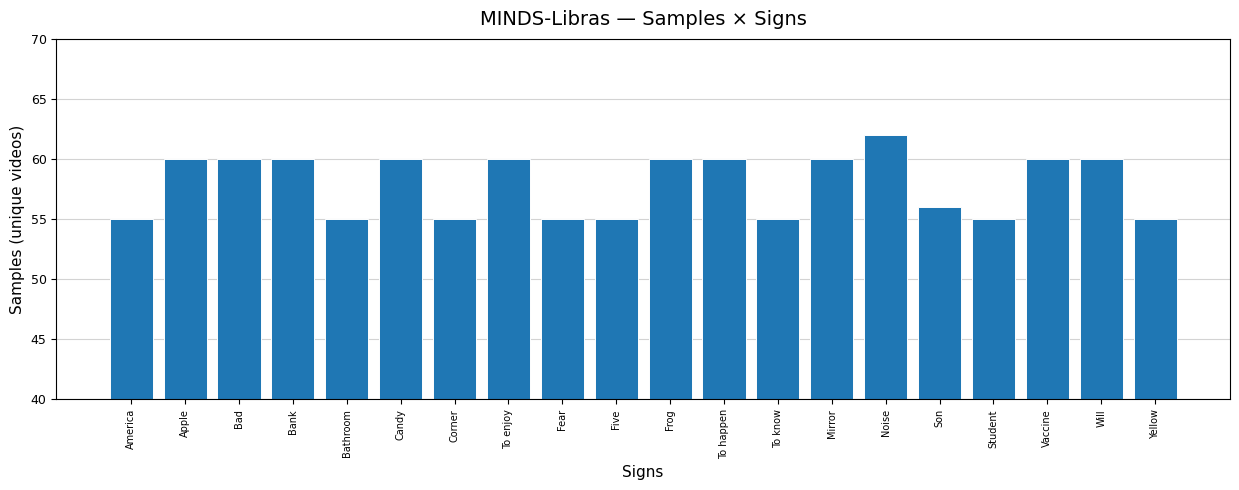

Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/minds_libras_samples.png
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/minds_libras_samples.pdf
Selected videos:
 - /Users/dani/Projetos/islr-subset/data/raw/minds/02AlunoSinalizador06-4.mp4 | person_06 | sign: Student
 - /Users/dani/Projetos/islr-subset/data/raw/minds/08BanheiroSinalizador11-3.mp4 | person_11 | sign: Bathroom
 - /Users/dani/Projetos/islr-subset/data/raw/minds/04AmericaSinalizador08-5.mp4 | person_08 | sign: America
Distinct persons selected: 3 -> ['person_06', 'person_11', 'person_08']
Selected signs: ['Student', 'Bathroom', 'America']

To freeze THIS panel in the dissertation, paste:
DATASETS["minds"]["sample_files"] = [
    '02AlunoSinalizador06-4.mp4',
    '08BanheiroSinalizador11-3.mp4',
    '04AmericaSinalizador08-5.mp4',
]


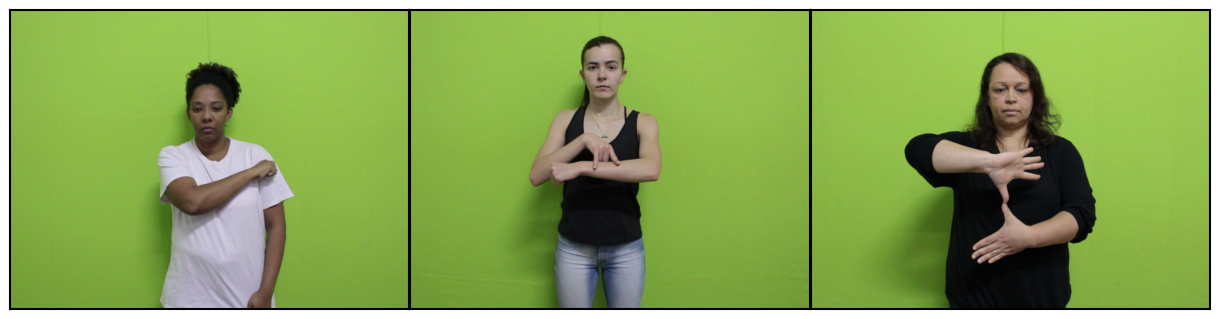


LIBRAS-UFOP
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/libras_ufop_samples_x_signs.png
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/libras_ufop_samples_x_signs.pdf
Label column : 'sign_key'
Video column : 'video_name'
Frame column : 'frame_id'
Unique signs : 56
Samples      : 3040


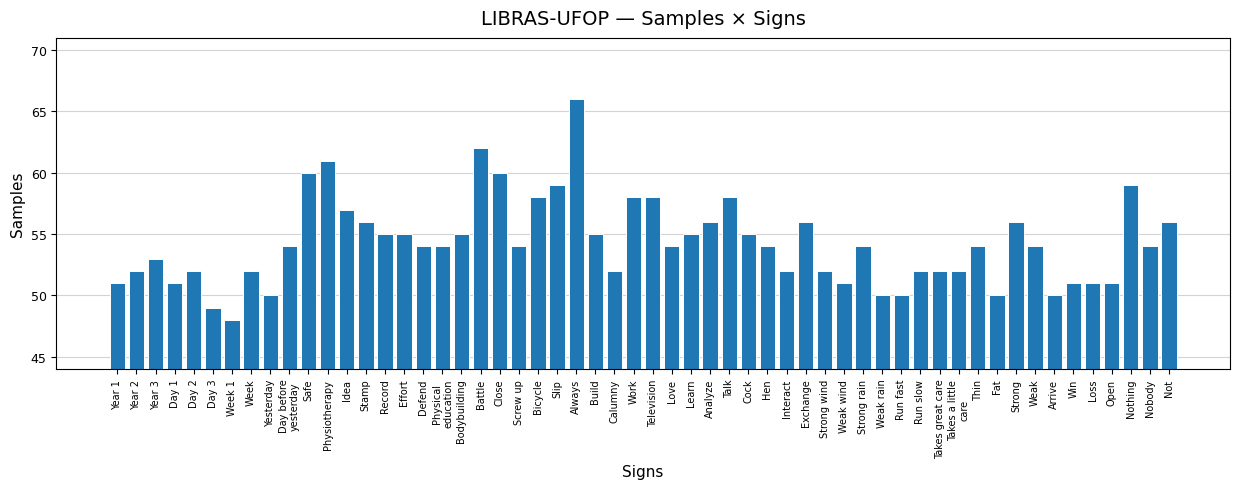

Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/libras_ufop_samples_x_signs_by_category.png
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/libras_ufop_samples_x_signs_by_category.pdf


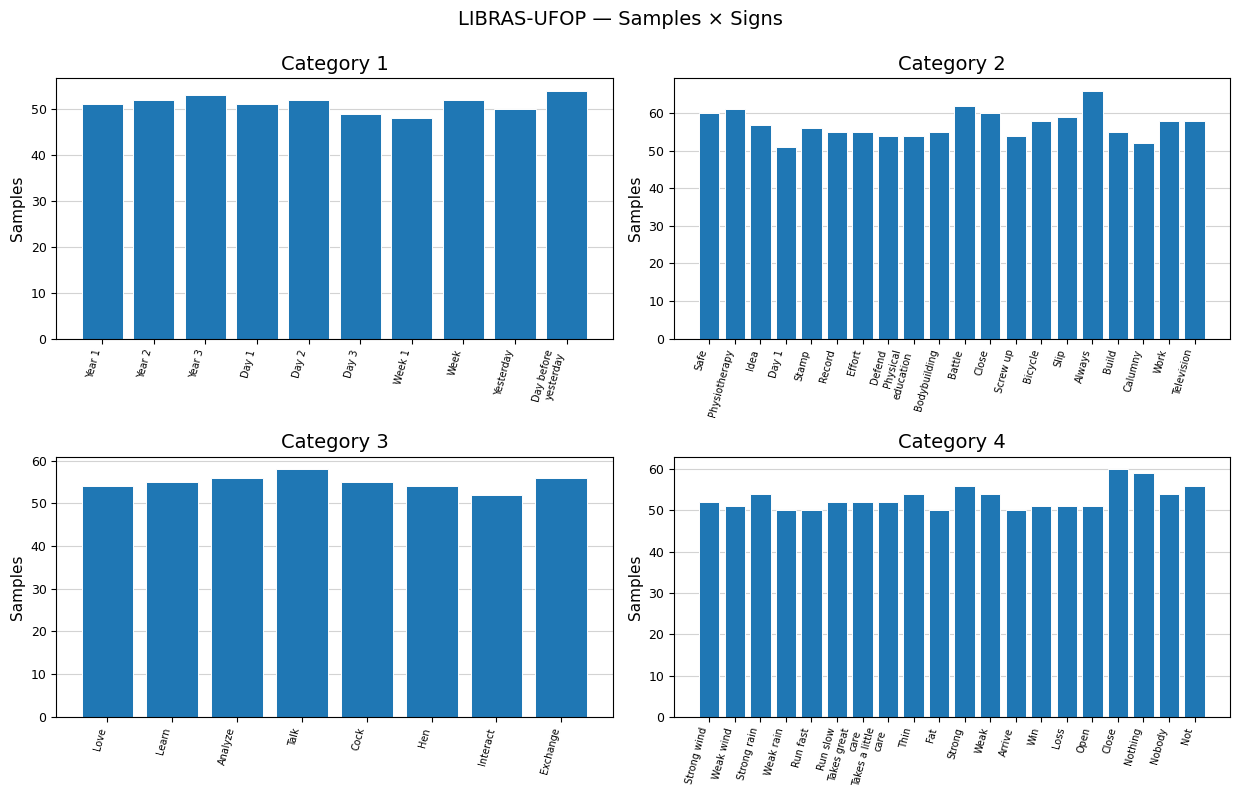

Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/libras_ufop_samples.png
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/libras_ufop_samples.pdf
Selected videos:
 - /Users/dani/Projetos/islr-subset/data/raw/ufop/raw/p3_c2_s12/Color.avi | person_003 | sign: Close
 - /Users/dani/Projetos/islr-subset/data/raw/ufop/raw/p5_c1_s7/Color.avi | person_005 | sign: Week 1
 - /Users/dani/Projetos/islr-subset/data/raw/ufop/raw/p4_c2_s2/Color.avi | person_004 | sign: Physiotherapy
Distinct persons selected: 3 -> ['person_003', 'person_005', 'person_004']
Selected signs: ['Close', 'Week 1', 'Physiotherapy']

To freeze THIS panel in the dissertation, paste:
DATASETS["ufop"]["sample_files"] = [
    'raw/p3_c2_s12/Color.avi',
    'raw/p5_c1_s7/Color.avi',
    'raw/p4_c2_s2/Color.avi',
]


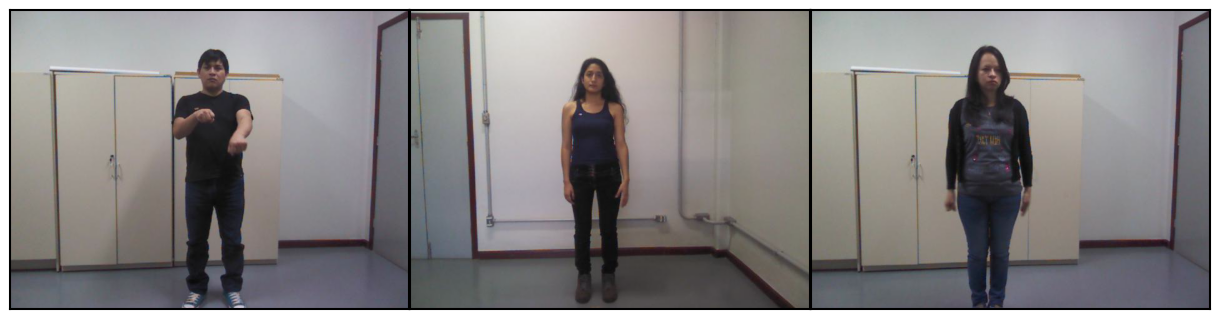


KSL
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/ksl_samples_x_signs.png
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/ksl_samples_x_signs.pdf
Label column : 'sign'
Video column : 'video_name'
Frame column : 'frame_id'
Unique signs : 67
Samples      : 1229


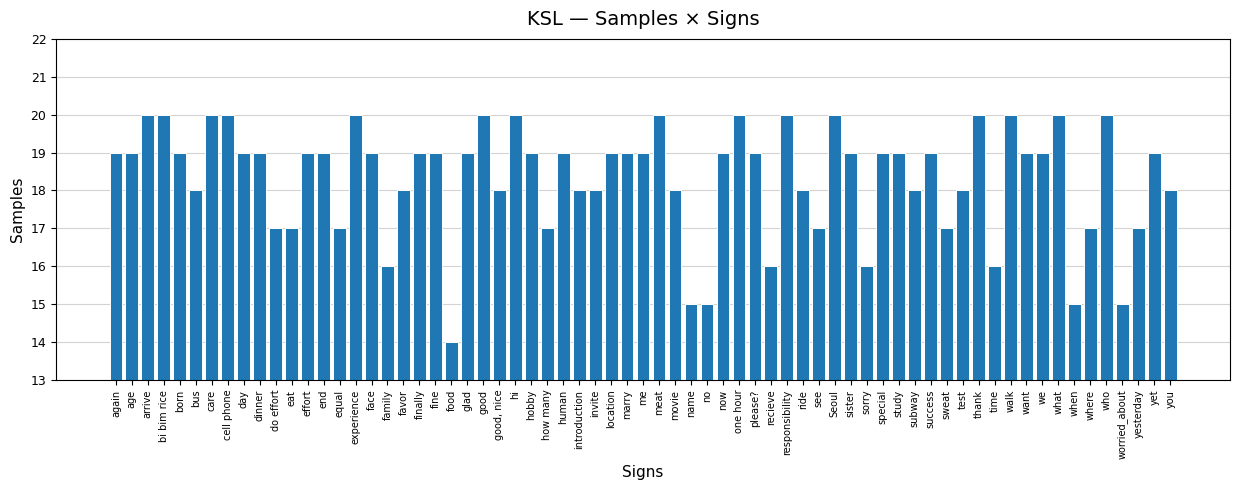

Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/ksl_samples.png
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/ksl_samples.pdf
Selected videos:
 - /Users/dani/Projetos/islr-subset/data/raw/ksl/22/16_22.MP4 | person_16 | sign: How many
 - /Users/dani/Projetos/islr-subset/data/raw/ksl/03/06_03.MP4 | person_06 | sign: Meat
 - /Users/dani/Projetos/islr-subset/data/raw/ksl/05/08_05.MP4 | person_08 | sign: Glad
Distinct persons selected: 3 -> ['person_16', 'person_06', 'person_08']
Selected signs: ['How many', 'Meat', 'Glad']

To freeze THIS panel in the dissertation, paste:
DATASETS["ksl"]["sample_files"] = [
    '22/16_22.MP4',
    '03/06_03.MP4',
    '05/08_05.MP4',
]


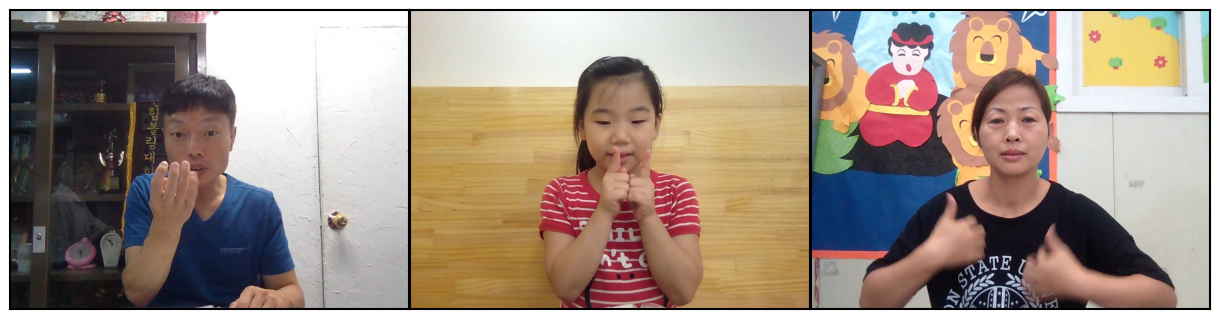


INCLUDE-50

INCLUDE-50 DATASET DIAGNOSTIC
------------------------------------------------------------
Raw official-class videos found: 943
Official classes found: 50
Samples          : 943
Classes          : 50
Samples/class    : 14-21
Current CSV      : /Users/dani/Projetos/islr-subset/data/interim/include50/include50_mediapipe_with_split.csv
CSV samples      : 929
CSV classes      : 50
Examples: ['Attack', 'Ball', 'Brown', 'Cat', 'Chair', 'Dress', 'Good afternoon', 'Green', 'Grey', 'How are you', 'Lamp', 'Night', 'Park', 'Plane', 'Religion']
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/include_50_samples_x_signs.png
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/include_50_samples_x_signs.pdf
Label column : 'official INCLUDE-50 sign'
Video column : 'predefined split/raw benchmark video'
Frame column : None
Unique signs : 50
Samples      : 943


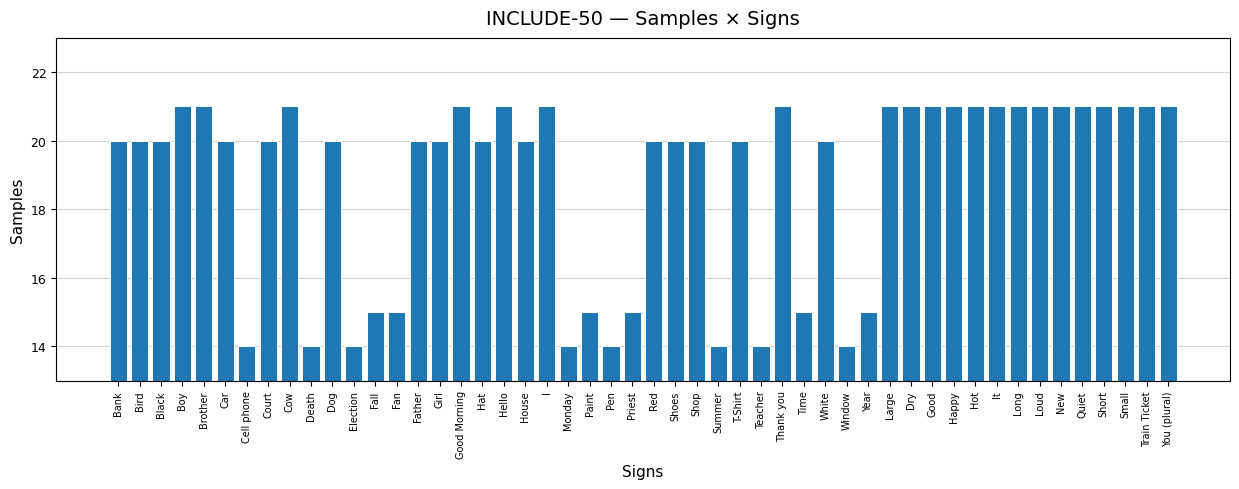

Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/include_50_samples.png
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/include_50_samples.pdf
Selected videos:
 - /Users/dani/Projetos/islr-subset/data/raw/include50/People_4of5/People/78. Girl/MVI_3818.MOV | 78. Girl | sign: 78. Girl
 - /Users/dani/Projetos/islr-subset/data/raw/include50/Places_1of4/Places/19. House/MVI_3595.MOV | 19. House | sign: 19. House
 - /Users/dani/Projetos/islr-subset/data/raw/include50/Adjectives_8of8/Adjectives/97. dry/MVI_5328.MOV | 97. dry | sign: 97. dry
Distinct persons selected: 3 -> ['78. Girl', '19. House', '97. dry']
Selected signs: ['78. Girl', '19. House', '97. dry']

To freeze THIS panel in the dissertation, paste:
DATASETS["include50"]["sample_files"] = [
    'People_4of5/People/78. Girl/MVI_3818.MOV',
    'Places_1of4/Places/19. House/MVI_3595.MOV',
    'Adjectives_8of8/Adjectives/97. dry/MVI_5328.MOV',
]


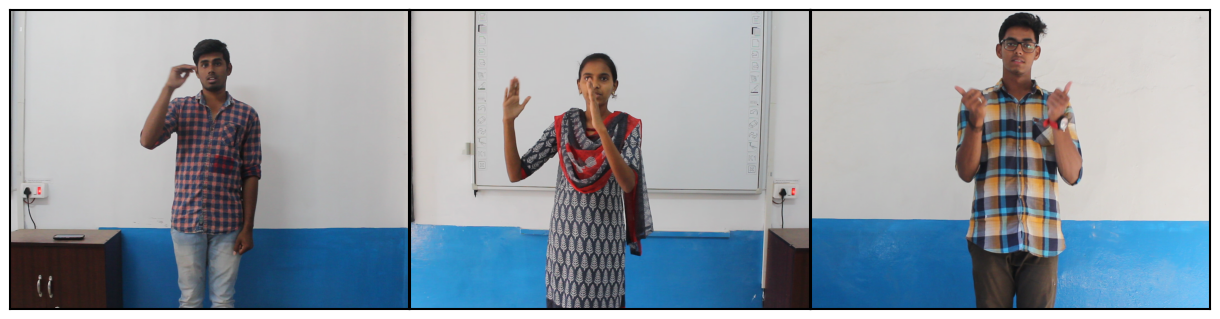

In [5]:
for dataset_key in ["minds", "ufop", "ksl", "include50"]:
    cfg = DATASETS[dataset_key]

    print("\n" + "=" * 80)
    print(cfg["display_name"])
    print("=" * 80)

    if dataset_key == "minds":
        try:
            print_minds_diagnostic(cfg)
        except Exception as exc:
            print("[MINDS DIAGNOSTIC ERROR]", exc)

    if dataset_key == "include50":
        try:
            print_include50_diagnostic(cfg)
        except Exception as exc:
            print("[INCLUDE-50 DIAGNOSTIC ERROR]", exc)

    try:
        plot_samples_per_sign(cfg)
        plt.show()

        if dataset_key == "ufop":
            plot_ufop_by_category(cfg)
            plt.show()
    except Exception as exc:
        print("[BAR CHART ERROR]", exc)

    try:
        make_sample_panel(cfg, n=3, frame_position=0.50, show_labels=False)
        plt.show()
    except Exception as exc:
        print("[SAMPLE PANEL ERROR]", exc)


## Optional: choose specific examples / raw-video paths

For dissertation figures, manually selecting visually representative examples is preferable.
If `sample_files` is provided, it overrides the random selection.

If you prefer random selection but want the result to be reproducible, set a seed:

```python
DATASETS["minds"]["random_seed"] = 42
DATASETS["ufop"]["random_seed"] = 42
```

If the notebook prints `videos: ... NOT FOUND`, first point `video_root` to the directory
that actually contains the original videos. For example:

```python
DATASETS["minds"]["video_root"] = Path("/path/to/MINDS-Libras")
DATASETS["ufop"]["video_root"] = Path("/path/to/LIBRAS-UFOP")
DATASETS["ksl"]["video_root"] = Path("/path/to/KSL")
DATASETS["include50"]["video_root"] = Path("/path/to/INCLUDE-50")
```

Then, if desired, force three specific examples using paths relative to `video_root`:

```python
DATASETS["minds"]["sample_files"] = [
    "01AcontecerSinalizador01-2.mp4",
    "08BanheiroSinalizador04-3.mp4",
    "10CincoSinalizador09-5.mp4",
]

DATASETS["ufop"]["sample_files"] = [
    "p001_xxx/Color.avi",
    "p002_xxx/Color.avi",
    "p003_xxx/Color.avi",
]

make_sample_panel(DATASETS["minds"], n=3, show_labels=False)
make_sample_panel(DATASETS["ufop"], n=3, show_labels=False)
```

For UFOP, the sample panel already filters to `Color.avi`, so `Depth.avi` will not be used.


## Optional: export the distributions as CSV

In [6]:
for dataset_key in ["minds", "ufop", "ksl", "include50"]:
    cfg = DATASETS[dataset_key]
    try:
        sample_df, _, _, _ = load_sample_level_index(cfg)

        counts = (
            sample_df.groupby("sign")
            .size()
            .rename("n_samples")
            .reset_index()
        )

        stem = cfg["display_name"].lower().replace(" ", "_").replace("-", "_")
        out_csv = OUTPUT_DIR / f"{stem}_samples_x_signs.csv"
        counts.to_csv(out_csv, index=False)
        print("Saved:", out_csv)

    except Exception as exc:
        print(cfg["display_name"], "->", exc)


Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/minds_libras_samples_x_signs.csv
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/libras_ufop_samples_x_signs.csv
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/ksl_samples_x_signs.csv
Saved: /Users/dani/Projetos/islr-subset/reports/figures/datasets/include_50_samples_x_signs.csv
